In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline




# Create DataFrame
df = pd.DataFrame({
    "Weight": [
        45, 58, 48, 60, 70, 78, 80, 90, 95, 78,
        82, 95, 105, 100, 85, 78, 50, 65, 76, 87,
        45, 56, 72
    ],
    
    "Height": [
        120, 135, 123, 145, 160, 162, 163, 175, 182, 170,
        176, 182, 175, 183, 170, 177, 140, 159, 150, 167,
        129, 140, 160
    ]
})

df.head(5)

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


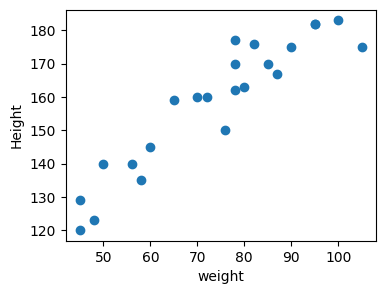

In [12]:
plt.figure(figsize=(4,3))
plt.scatter(x=df['Weight'],y=df['Height'])
plt.xlabel("weight")
plt.ylabel("Height")
plt.show()

In [13]:
# correlation 

df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


<Figure size 400x400 with 0 Axes>

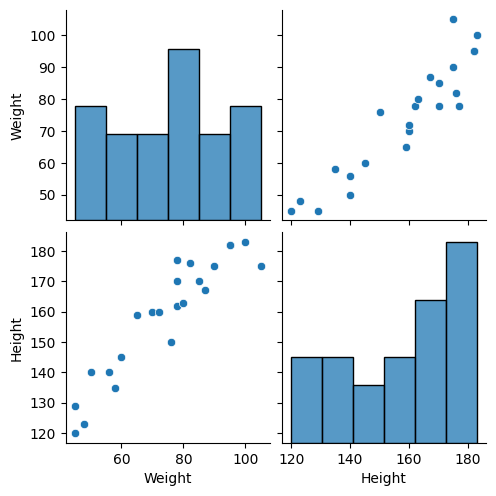

In [14]:
import seaborn as sns
plt.figure(figsize=(4,4))
sns.pairplot(df)
plt.show()

In [15]:
# independet and dependent features

X=df[['Weight']] # independent feature must be in a 2-d array or in dataframe
Y=df['Height'] # This variable can be in series form or 1-D array

In [16]:
# Train Test Split

from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.25,random_state=42)

In [18]:
# Standardization
from sklearn.preprocessing import StandardScaler

In [19]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

In [20]:
X_test = scaler.transform(X_test)

In [21]:
# Apply Linear Regression

from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
print("Coffecients or slope",lr.coef_)

Coffecients or slope [17.2982057]


In [24]:
print("Intercept",lr.intercept_)

Intercept 156.47058823529412


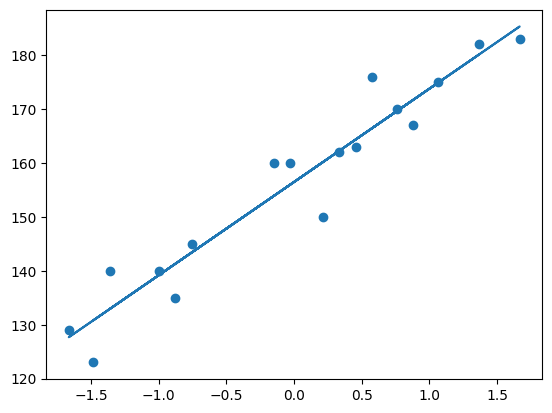

In [25]:
# plot Training data plot for best fit line 

plt.scatter(X_train,Y_train)
plt.plot(X_train,lr.predict(X_train))

In [26]:
# Prediction for test data

y_pred = lr.predict(X_test)

In [27]:
# Performance metric

from sklearn.metrics import mean_squared_error,mean_absolute_error
mse = mean_squared_error(Y_test,y_pred)
mae = mean_absolute_error(Y_test,y_pred)
rmse = np.sqrt(mse)
print("MSE",mse)
print("MAE",mae)
print("RMSE",rmse)

MSE 114.84069295228699
MAE 9.66512588679501
RMSE 10.716374991212605


In [29]:
from sklearn.metrics import r2_score
score = r2_score(Y_test,y_pred)
print(score*100)

73.60826717981276


In [31]:
n = X_test.shape[0]   # number of rows
p = X_test.shape[1]   # number of features
adjusted_r2 = 1 - ((1 - score) * (n - 1)) / (n - p - 1)

print(adjusted_r2*100)

67.01033397476594


In [32]:
# OLS Linear Regreesion

import statsmodels.api as sm

model = sm.OLS(Y_train,X_train).fit()

In [33]:
prediction = model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [35]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sat, 23 May 2026   Prob (F-statistic):                       0.664
Time:                        20:21:59   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\Abhishek Chattaraj\anaconda3\envs\visa_mlops\lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [37]:
# prediciton for new data
lr.predict(scaler.transform([[72]]))

c:\Users\Abhishek Chattaraj\anaconda3\envs\visa_mlops\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])